<a href="https://colab.research.google.com/github/Poonam4385/Deep-learning/blob/main/Agricultural_crops_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: import required Lib

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mdwaquarazam/agricultural-crops-image-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'agricultural-crops-image-classification' dataset.
Path to dataset files: /kaggle/input/agricultural-crops-image-classification


In [ ]:
print("Dataset downloaded successfully!")
print("Saved at:", path)
print("Files:", os.listdir(path))

Dataset downloaded successfully!
Saved at: /kaggle/input/agricultural-crops-image-classification
Files: ['Agricultural-crops']


In [ ]:
# Path of datasets
base_data_dir = os.path.join(path, 'Agricultural-crops')

In [ ]:
# Step 3: Make directory of training and testing

train_dir = os.path.join(base_data_dir, 'train')
validation_dir = os.path.join(base_data_dir, 'validation')

In [ ]:
train_Agriculture_crop_dir = os.path.join(train_dir, 'Agriculture-crops')
validation_Agriculture_crop_dir = os.path.join(validation_dir, 'Agriculture-crops')

In [ ]:
# The directories 'train_Agriculture_crop_dir' and 'validation_Agriculture_crop_dir' do not exist.
# Instead, we will print the number of unique crop categories found in base_data_dir,
# which are already calculated in num_Agricultural_crops_train and num_Agricultural_crops_validation.
print(f"Number of crop categories for training: {num_Agricultural_crops_train}")
print(f"Number of crop categories for validation: {num_Agricultural_crops_validation}")

Number of crop categories for training: 30
Number of crop categories for validation: 30


In [ ]:
# Step 5: Check the len of train and validation Agricultural-crops
# Since 'train' and 'validation' subdirectories do not exist directly under base_data_dir,
# we will count the number of class directories in base_data_dir instead.
num_Agricultural_crops_train = len(os.listdir(base_data_dir))

# Assuming for now that validation also refers to the number of classes in the base directory
num_Agricultural_crops_validation = len(os.listdir(base_data_dir))

total_train = num_Agricultural_crops_train + num_Agricultural_crops_train
total_val = num_Agricultural_crops_validation + num_Agricultural_crops_validation

In [ ]:
# Check the content of base_data_dir
print(f"Content of {base_data_dir}: {os.listdir(base_data_dir)}")

Content of /kaggle/input/agricultural-crops-image-classification/Agricultural-crops: ['tomato', 'chilli', 'clove', 'pineapple', 'vigna-radiati(Mung)', 'Olive-tree', 'coconut', 'papaya', 'Tobacco-plant', 'jute', 'jowar', 'gram', 'tea', 'maize', 'wheat', 'soyabean', 'Pearl_millet(bajra)', 'Lemon', 'Fox_nut(Makhana)', 'mustard-oil', 'sugarcane', 'almond', 'Cucumber', 'sunflower', 'cotton', 'banana', 'Cherry', 'cardamom', 'rice', 'Coffee-plant']


In [ ]:
# Step 5: Take the Hyperparamter
batch_size = 128
epochs = 5
IMG_HEIGHT = 150
IMG_WIDTH = 150

In [ ]:
# Step 6: Data Augmentation
train_image_generator = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# validation
validation_image_generator = ImageDataGenerator(rescale=1. / 255)

In [ ]:
# Step 6: Create the flow directory

train_data_gen = train_image_generator.flow_from_directory(
    batch_size=batch_size,
    directory=base_data_dir,  # Corrected to use base_data_dir
    shuffle=True,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode='categorical'  # Corrected for multiple classes
)

val_data_gen = validation_image_generator.flow_from_directory(
    batch_size=batch_size,
    directory=base_data_dir,  # Corrected to use base_data_dir
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode='categorical'  # Corrected for multiple classes
)


Found 829 images belonging to 30 classes.
Found 829 images belonging to 30 classes.


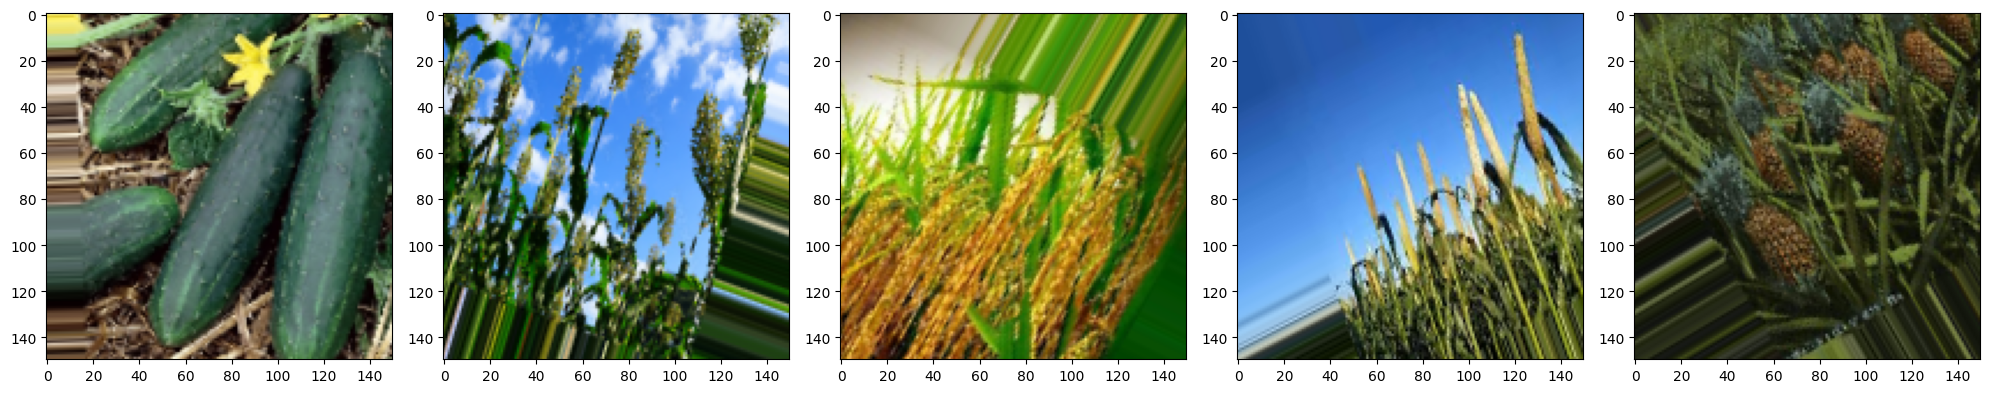

In [ ]:
# show the sample of training data

sample_training_imges, _ = next(train_data_gen)

# make the function to plot the images in the form grid
#with 1 rows and 5 columns where images are placed in each column.


def plotImages(images_arr):
    fig, axes = plt.subplots(1, 5, figsize=(20, 20))
    axes = axes.flatten()
    for img, ax in zip(images_arr, axes):
        ax.imshow(img)
    plt.tight_layout()
    plt.show()

plotImages(sample_training_imges[:5])


In [ ]:
# Step 8: Building model

model = Sequential([
    Conv2D(16, 3, padding='same', activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(),
    Dropout(0.2),

    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Dropout(0.2),

    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Dropout(0.3),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(num_Agricultural_crops_train) # Changed to 30 for multi-class classification
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Step 9: Model compile

model.compile(optimizer=Adam(learning_rate=0.001),
              loss=CategoricalCrossentropy(from_logits=True), # Changed for multi-class classification
              metrics=['accuracy'])

In [ ]:
# model summary
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │    10,617,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 30)             │        15,390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,656,318 (40.65 MB)

 Trainable params: 10,656,318 (40.65 MB)

 Non-trainable params: 0 (0.00 B)

In [99]:
# Step 10 : Model Training
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)

history = model.fit(
    train_data_gen,
    steps_per_epoch=total_train // batch_size,
    epochs=30,
    validation_data=val_data_gen,
    validation_steps=total_val // batch_size,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 49s 7s/step - accuracy: 0.0277 - loss: 4.4383 - val_accuracy: 0.0338 - val_loss: 3.4032 - learning_rate: 0.0010
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 88s 8s/step - accuracy: 0.0398 - loss: 3.4111 - val_accuracy: 0.0434 - val_loss: 3.4005 - learning_rate: 0.0010
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 72s 7s/step - accuracy: 0.0277 - loss: 3.4003 - val_accuracy: 0.0470 - val_loss: 3.4004 - learning_rate: 0.0010
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 92s 8s/step - accuracy: 0.0458 - loss: 3.3997 - val_accuracy: 0.0470 - val_loss: 3.3997 - learning_rate: 0.0010
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 72s 6s/step - accuracy: 0.0483 - loss: 3.3948 - val_accuracy: 0.0470 - val_loss: 3.3941 - learning_rate: 0.0010
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 43s 6s/step - accuracy: 0.0458 - loss: 3.3964 - val_accuracy: 0.0470 - val_loss: 3.3883 - learning_rate: 0.0010
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 83s 6s/step - accuracy: 0.0253 - loss: 3.3879 - val_accuracy: 0.0483 - val_l

In [101]:
# Step 11: Model matrics display
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

train_loss = history.history['loss']
val_loss = history.history['val_loss']

#print
print("Training Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Training Loss:", train_loss)
print("Validation Loss:", val_loss)

Training Accuracy: [0.027744270861148834, 0.039806995540857315, 0.027744270861148834, 0.045838359743356705, 0.04825090616941452, 0.045838359743356705, 0.02533172443509102, 0.04704463109374046, 0.05307599529623985, 0.04945717751979828, 0.06393244862556458, 0.05910735949873924, 0.06996381282806396, 0.09891435503959656, 0.09891435503959656, 0.08926417678594589, 0.09891435503959656, 0.11821471899747849, 0.11821471899747849, 0.12786489725112915, 0.1290711760520935, 0.13872134685516357, 0.1519903540611267, 0.1556091606616974, 0.17008443176746368, 0.1869722604751587, 0.1893848031759262, 0.201447531580925, 0.20627261698246002, 0.21351025998592377]
Validation Accuracy: [0.033775635063648224, 0.04342581331729889, 0.04704463109374046, 0.04704463109374046, 0.04704463109374046, 0.04704463109374046, 0.04825090616941452, 0.04704463109374046, 0.04704463109374046, 0.045838359743356705, 0.07599517703056335, 0.08805789798498154, 0.12183353304862976, 0.11700844019651413, 0.11942099034786224, 0.13630880415

Text(0.5, 1.0, 'Training and Validation Accuracy')

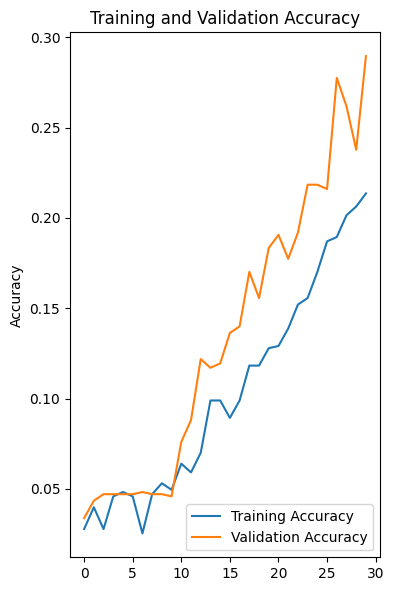

In [102]:
# make plot of accuracy of training and validation
plt.figure(figsize=(4,15))
plt.subplot(2, 1, 1)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')

plt.title('Training and Validation Accuracy')


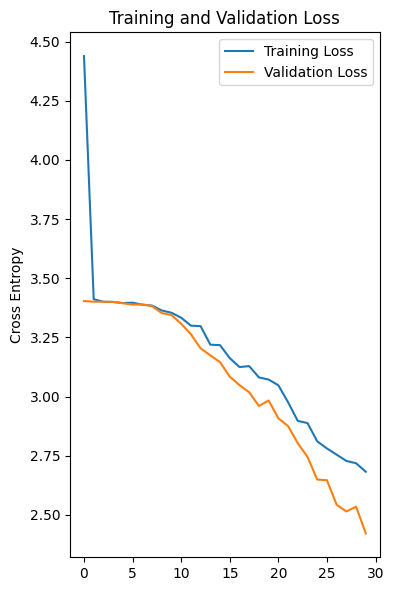

In [103]:
# make the plot for validation loss
plt.figure(figsize=(4, 15))
plt.subplot(2, 1, 2)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.title('Training and Validation Loss')
plt.show()

In [106]:
# Step 12: Prediction and Testing

path = "/content/Tomato.jpg"

from keras.models import load_model
import cv2
import numpy as np

model = load_model('model.h5')

img = cv2.imread(path)
img = cv2.resize(img, (150, 150))

y_hat = model.predict(np.expand_dims(img, axis=0))

if y_hat[0][0] > 0.5:
    print("Tomato")

else:
    print("No")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
Tomato
